# Director Skill Sets Table 7 - Death dates only

In [1]:
import pandas_datareader.data as web #to collect data
import datetime as dt #to specify start and end dates

# import yfinance as yf

import eventstudy as es
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mpl_toolkits as mplot3d
%matplotlib inline
import seaborn as sns

import scipy.stats as stats
from scipy.stats.mstats import winsorize
from scipy.spatial.distance import cdist


from sklearn.neighbors import NearestNeighbors

import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.regression.rolling import RollingOLS

from sklearn.preprocessing import StandardScaler

from patsy import dmatrices
from tqdm.notebook import tqdm
tqdm.pandas()

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

In [2]:
import_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] CAPM CAR\car_output4"
output_folder_path = "analysis_outputs"
# pca_input_folder_path = rf"..\..\..\[IN USE] Rookie Directors\[1.5] Director Skills PCA\director_skills_pca"
firm_input_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[2] Firm Level Wrangling\Firm level Iterative\Firm Lev + Fin\City level\city_lev_output"
filtering_folder_path = rf"..\..\..\..\[IN USE] Rookie Directors\[4] FF3 CAR\car_filtering"
supporting_folder_path = "supporting_datafiles"

In [3]:
dirFirm00 = pd.read_pickle(rf"{import_folder_path}\Director Level_MF_CAR.pkl")
dirFirm00 = dirFirm00.loc[ dirFirm00["date_source"] == "Date of Demise"].reset_index(drop = True)

# pca = pd.read_pickle(rf"{pca_input_folder_path}\Main_Director_COMPLETE_PCA.pkl")
firm = pd.read_pickle(rf"{firm_input_folder_path}\Main_Firm_COMPLETE.pkl")

In [4]:
# pca_col = [
#     "Person Code", "AsOnDate", "Symbol",
#     "SkillsetIndex", "SkillsetGeneralistDummy",
#     "PC1_FactorScore", "PC1_FactorScore_Standardised"
# ]

# pca2 = pca[pca_col].copy()
# dirFirm00 = dirFirm0.merge(pca2, on = ["Person Code", "AsOnDate", "Symbol"], how = "left")

In [26]:
firm_col = [
    "AsOnDate", "Symbol",

    "PercentWomenDir", "PercentBusyDir",
    "LnBoardSize", "PercentIndep",
    "Promoters_percent", "NonpromoterInstitutions_percent", "RD to Assets",
    "ln_marcap", "ln_rdtoassets", "Debt to equity ratio", # control variables
    
    "FamilyOwnedFamilyCeoChair25", "promoterholding25", "HasFamilyChairmanAndCEO",
]

firm2 = firm[firm_col].copy()
dirFirm = dirFirm00.merge(firm2, on = ["AsOnDate", "Symbol"], how = "left")

In [27]:
# dirFirm data wrangling if any:
dirFirm["Year of Study"] = [x.year for x in dirFirm["Date of Study"]]

dirFirm = dirFirm.drop_duplicates(subset = ["Person Code", "Company", "Date of Study"]).reset_index(drop = True)

dirFirm["ln_dirage"] = np.log(dirFirm["Age"] + 1).astype("float")
dirFirm["ln_directorships"] = np.log((dirFirm["CompCountCurrTotalAB"] - 1) + 1).astype("float")

In [28]:
dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\3673678293.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dirFirm.replace([np.inf, -np.inf], pd.NA, inplace = True)


# PSM

## Verifying and removing those rows with no control data points

In [29]:
# Sample constraints ---> govtdummy==0 & findummy==0 & asonyear>2012
# dirFirm.columns.to_list()

In [30]:
dirFirm["IsDualityChairmanMD"] = dirFirm["IsDualityChairmanMD"].astype(int)


dirFirm["NIC_1digit"] = dirFirm["NIC code"].dropna().apply(lambda x: x[0:1])
dirFirm["NIC_1digit"] = dirFirm["NIC_1digit"]

# dirFirm.loc[dirFirm["RD to Assets"] == 0, "ln_rdtoassets"] = 0

psmSample = dirFirm.loc[ (dirFirm["Year of Study"] >= 2013) 
    & (dirFirm["govtdummy"] == 0) & (dirFirm["findummy"] == 0) ].copy()
#.dropna(subset = controlVars).dropna(subset = dependentVar).copy()

# psmSample["DummySum"] = psmSample["IsRookie"] + psmSample["IsNonRookie"]
psmSample["DummySumIndep"] = psmSample["IsRookieIndep"] + psmSample["IsNonRookieIndep"]

# psmSampleAll = psmSample.loc[ psmSample["DummySum"] == 1 ].reset_index(drop = True)
# psmSampleAll = psmSampleAll.loc[ ~psmSampleAll.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

psmSampleIndep = psmSample.loc[ psmSample["DummySumIndep"] == 1 ].reset_index(drop = True)
# psmSampleIndep = psmSampleIndep.loc[ ~psmSampleIndep.duplicated(subset = ["AsOnDate", "Symbol", "Appointment Date"], keep = False)]

## CAR windsorization

       winsorised_120CAR3  nonwinsorised_120CAR3
count          301.000000             301.000000
mean            -0.003596              -0.003596
std              0.054653               0.054653
min             -0.237923              -0.237923
25%             -0.036323              -0.036323
50%             -0.006224              -0.006224
75%              0.026115               0.026115
max              0.215313               0.215313


Top values and their count:  nonwinsorised_120CAR3
0.101145    1
0.103298    1
0.103476    1
0.107487    1
0.121585    1
0.137130    1
0.160104    1
0.166476    1
0.167355    1
0.215313    1
Name: count, dtype: int64





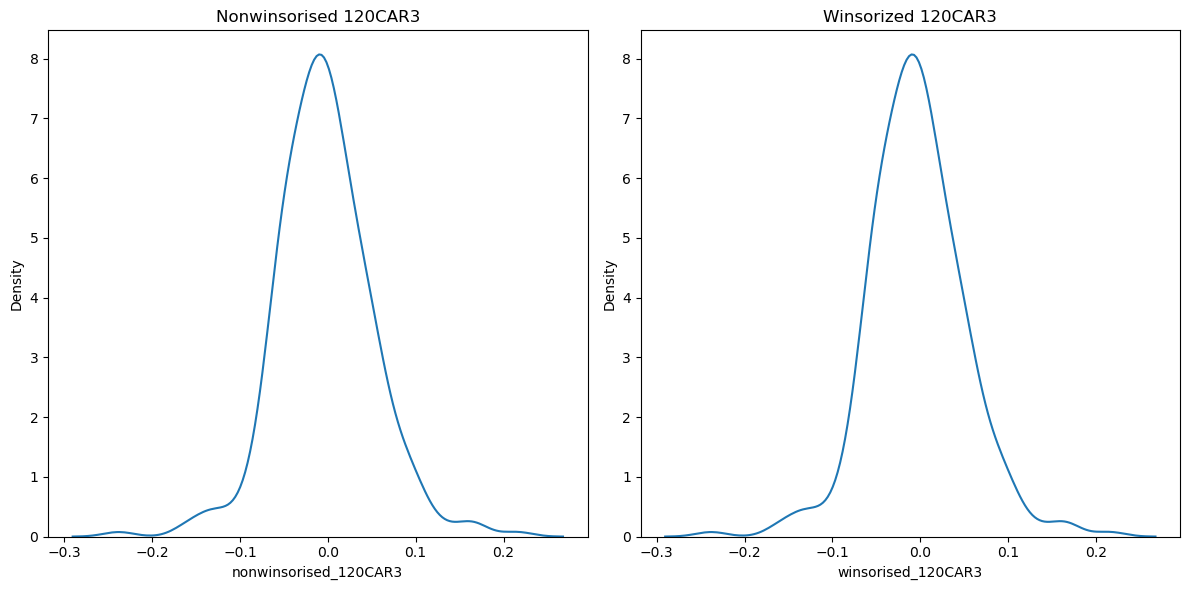

       winsorised_120CAR5  nonwinsorised_120CAR5
count          301.000000             301.000000
mean            -0.050938              -0.050938
std              0.070983               0.070983
min             -0.318701              -0.318701
25%             -0.086538              -0.086538
50%             -0.053074              -0.053074
75%             -0.016500              -0.016500
max              0.212517               0.212517


Top values and their count:  nonwinsorised_120CAR5
0.091408    1
0.092222    1
0.106260    1
0.107048    1
0.114758    1
0.119164    1
0.130520    1
0.141853    1
0.196030    1
0.212517    1
Name: count, dtype: int64





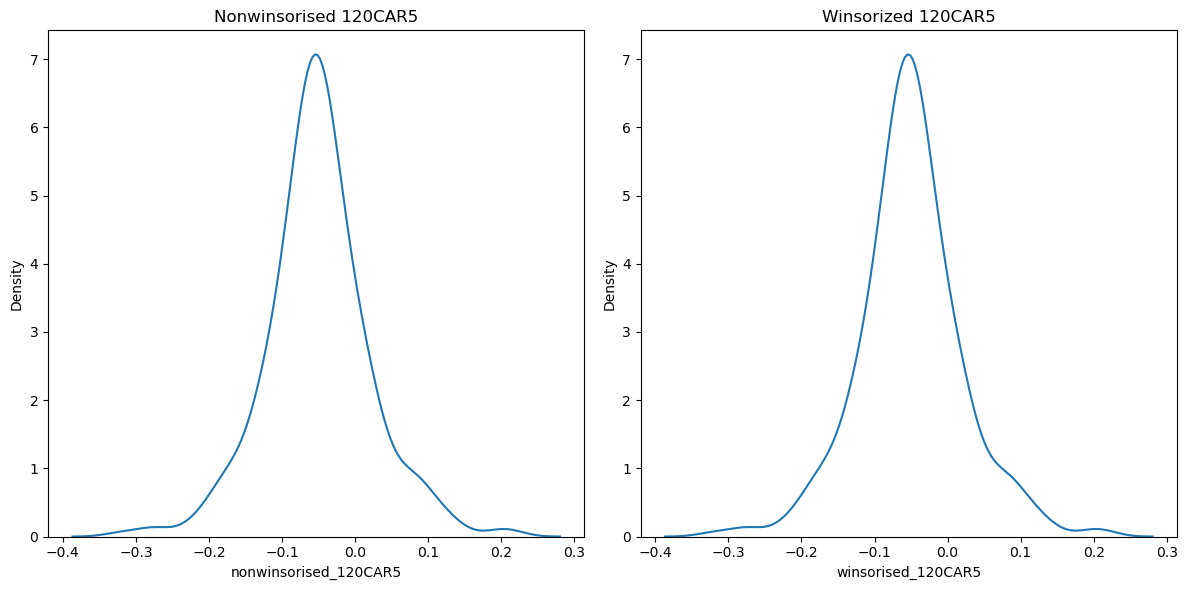

       winsorised_120CAR7  nonwinsorised_120CAR7
count          301.000000             301.000000
mean            -0.101450              -0.101450
std              0.095970               0.095970
min             -0.416580              -0.416580
25%             -0.153009              -0.153009
50%             -0.105162              -0.105162
75%             -0.055490              -0.055490
max              0.541790               0.541790


Top values and their count:  nonwinsorised_120CAR7
0.085283    1
0.086113    1
0.093562    1
0.103039    1
0.104947    1
0.105479    1
0.120722    1
0.122856    1
0.391124    1
0.541790    1
Name: count, dtype: int64





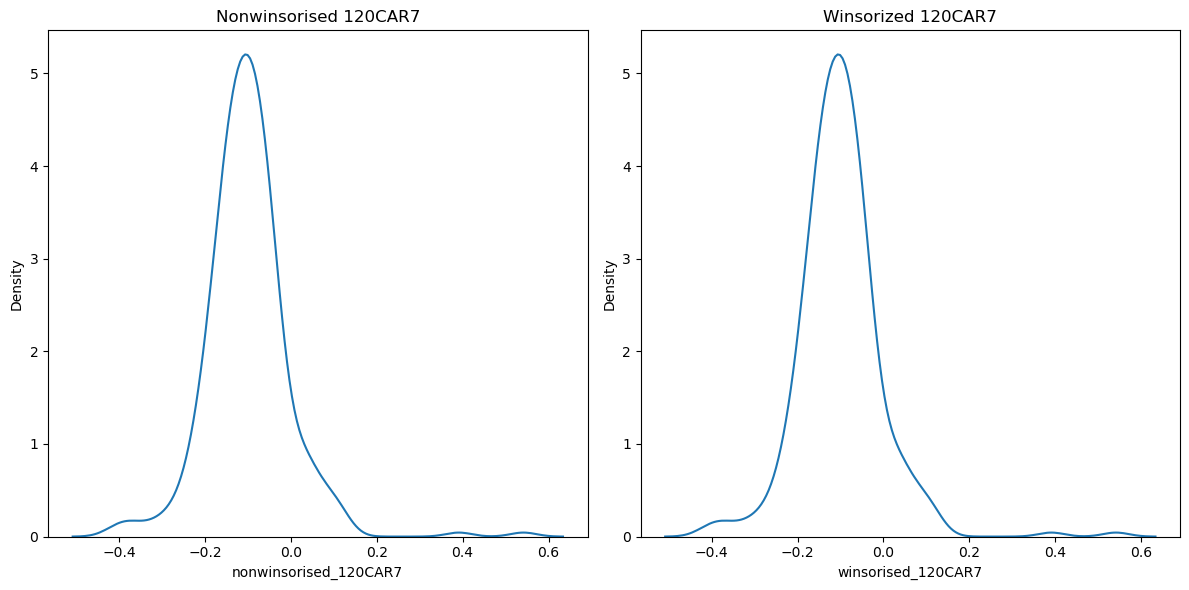

       winsorised_120CAR11  nonwinsorised_120CAR11
count           301.000000              301.000000
mean             -0.196858               -0.196858
std               0.126469                0.126469
min              -0.624257               -0.624257
25%              -0.269506               -0.269506
50%              -0.195160               -0.195160
75%              -0.124660               -0.124660
max               0.268643                0.268643


Top values and their count:  nonwinsorised_120CAR11
0.034597    1
0.071375    1
0.074439    1
0.088689    1
0.104092    1
0.111354    1
0.144658    1
0.212059    1
0.240275    1
0.268643    1
Name: count, dtype: int64





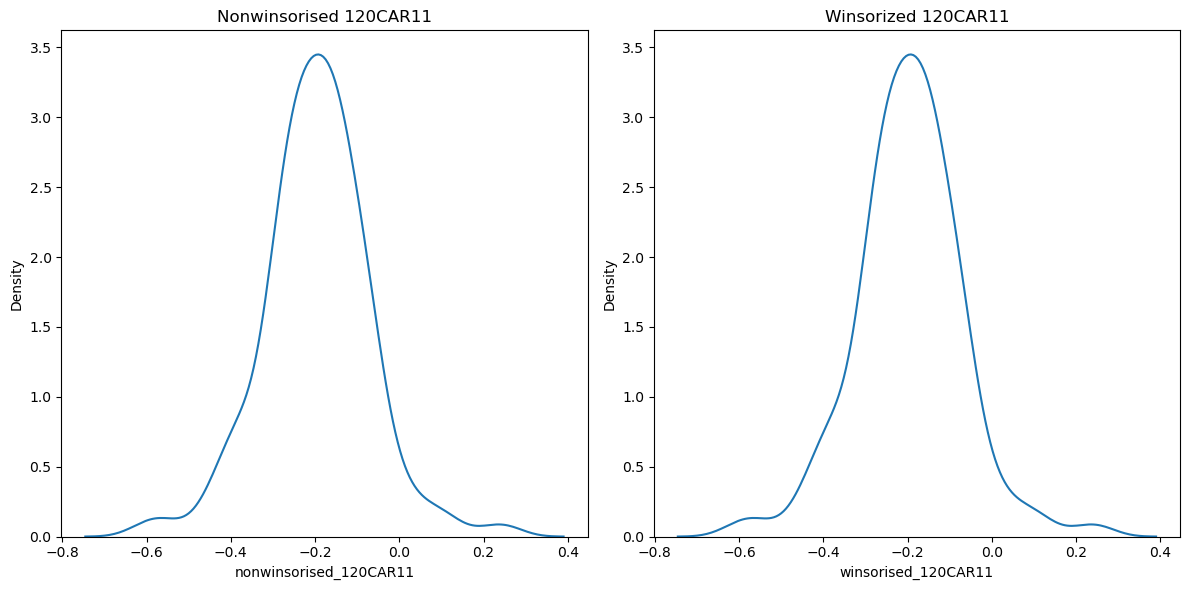

       winsorised_150CAR3  nonwinsorised_150CAR3
count          301.000000             301.000000
mean            -0.003708              -0.003708
std              0.054364               0.054364
min             -0.231427              -0.231427
25%             -0.038166              -0.038166
50%             -0.006075              -0.006075
75%              0.027337               0.027337
max              0.219026               0.219026


Top values and their count:  nonwinsorised_150CAR3
0.096628    1
0.100288    1
0.102454    1
0.108727    1
0.113018    1
0.135395    1
0.162234    1
0.164167    1
0.167139    1
0.219026    1
Name: count, dtype: int64





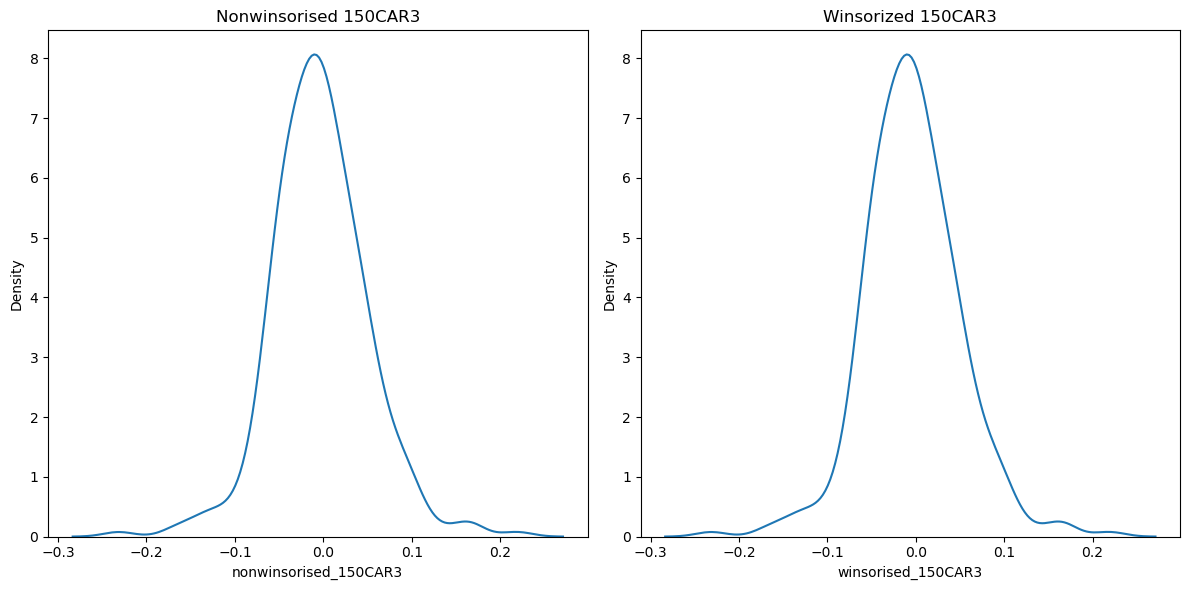

       winsorised_150CAR5  nonwinsorised_150CAR5
count          301.000000             301.000000
mean            -0.050914              -0.050914
std              0.070469               0.070469
min             -0.314709              -0.314709
25%             -0.085914              -0.085914
50%             -0.053073              -0.053073
75%             -0.016055              -0.016055
max              0.209175               0.209175


Top values and their count:  nonwinsorised_150CAR5
0.089079    1
0.093607    1
0.106404    1
0.107362    1
0.109173    1
0.116026    1
0.121178    1
0.140368    1
0.198402    1
0.209175    1
Name: count, dtype: int64





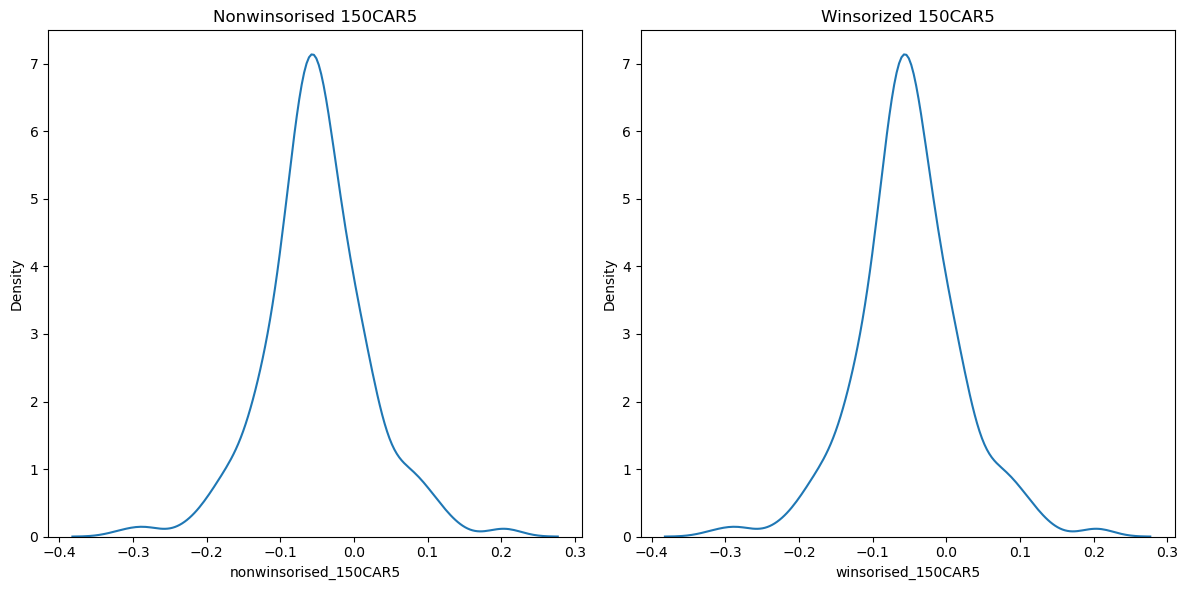

       winsorised_150CAR7  nonwinsorised_150CAR7
count          301.000000             301.000000
mean            -0.101350              -0.101350
std              0.095527               0.095527
min             -0.416627              -0.416627
25%             -0.152444              -0.152444
50%             -0.102943              -0.102943
75%             -0.055865              -0.055865
max              0.530379               0.530379


Top values and their count:  nonwinsorised_150CAR7
0.078290    1
0.089907    1
0.098789    1
0.101852    1
0.103785    1
0.106790    1
0.115710    1
0.120132    1
0.397046    1
0.530379    1
Name: count, dtype: int64





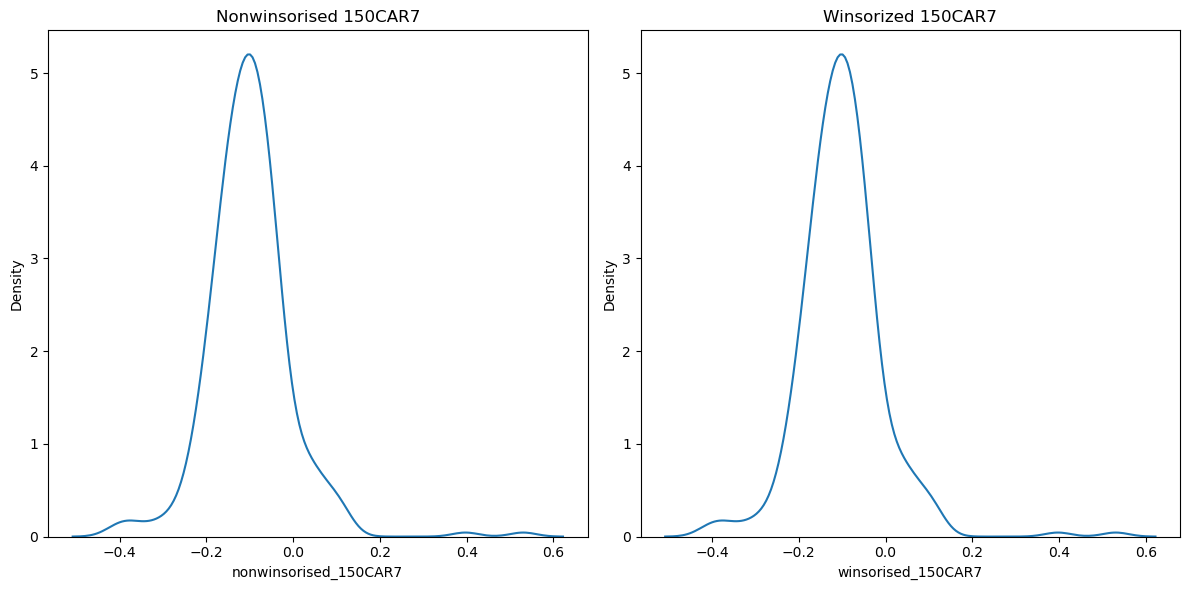

       winsorised_150CAR11  nonwinsorised_150CAR11
count           301.000000              301.000000
mean             -0.196817               -0.196817
std               0.126129                0.126129
min              -0.633743               -0.633743
25%              -0.272110               -0.272110
50%              -0.195831               -0.195831
75%              -0.125176               -0.125176
max               0.258974                0.258974


Top values and their count:  nonwinsorised_150CAR11
0.036767    1
0.051508    1
0.072645    1
0.100061    1
0.100707    1
0.103161    1
0.148668    1
0.220097    1
0.244827    1
0.258974    1
Name: count, dtype: int64





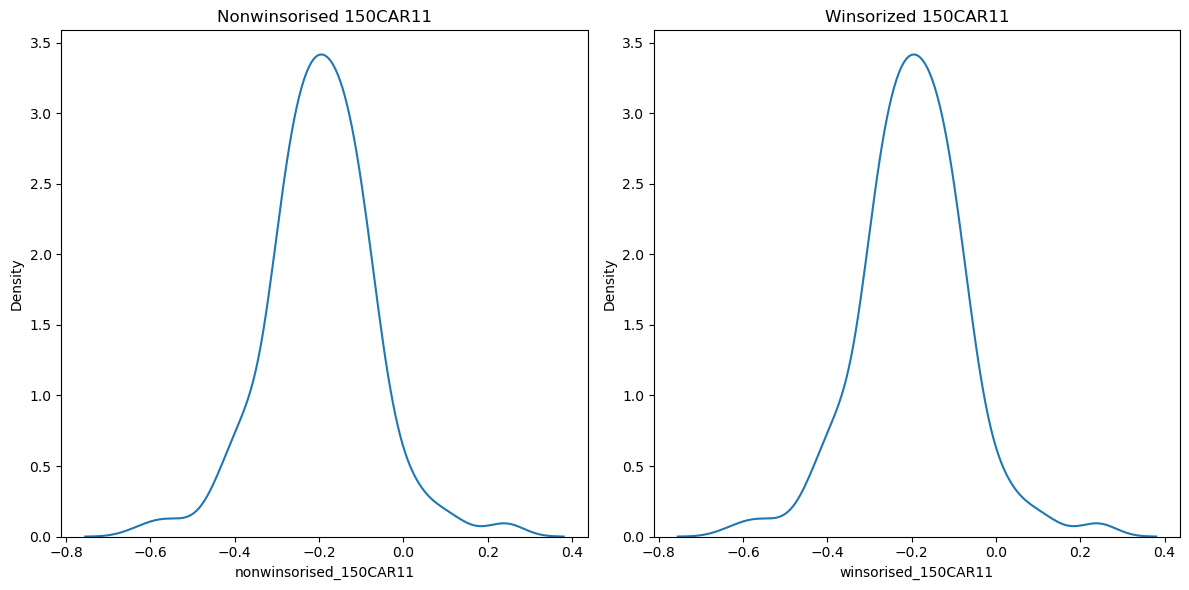

       winsorised_180CAR3  nonwinsorised_180CAR3
count          301.000000             301.000000
mean            -0.003349              -0.003349
std              0.054167               0.054167
min             -0.231893              -0.231893
25%             -0.038306              -0.038306
50%             -0.006629              -0.006629
75%              0.028290               0.028290
max              0.218510               0.218510


Top values and their count:  nonwinsorised_180CAR3
0.097271    1
0.103241    1
0.103363    1
0.109538    1
0.109687    1
0.138364    1
0.164057    1
0.169916    1
0.170428    1
0.218510    1
Name: count, dtype: int64





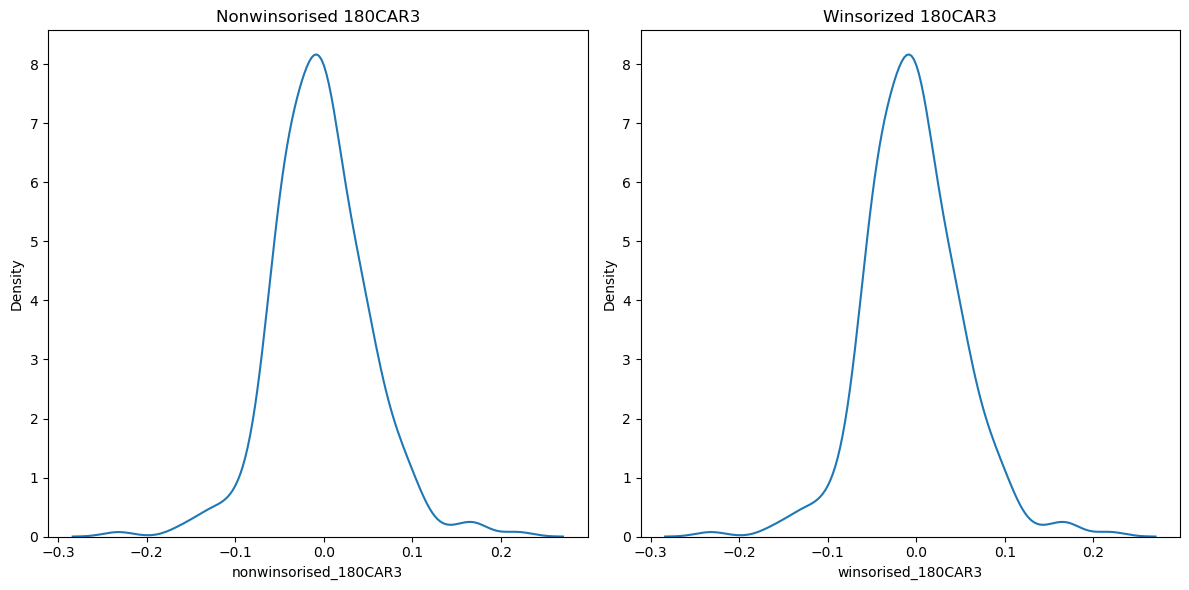

       winsorised_180CAR5  nonwinsorised_180CAR5
count          301.000000             301.000000
mean            -0.050646              -0.050646
std              0.070106               0.070106
min             -0.309244              -0.309244
25%             -0.085201              -0.085201
50%             -0.052843              -0.052843
75%             -0.015381              -0.015381
max              0.214968               0.214968


Top values and their count:  nonwinsorised_180CAR5
0.089599    1
0.090567    1
0.101892    1
0.108749    1
0.111000    1
0.116213    1
0.116245    1
0.144753    1
0.197642    1
0.214968    1
Name: count, dtype: int64





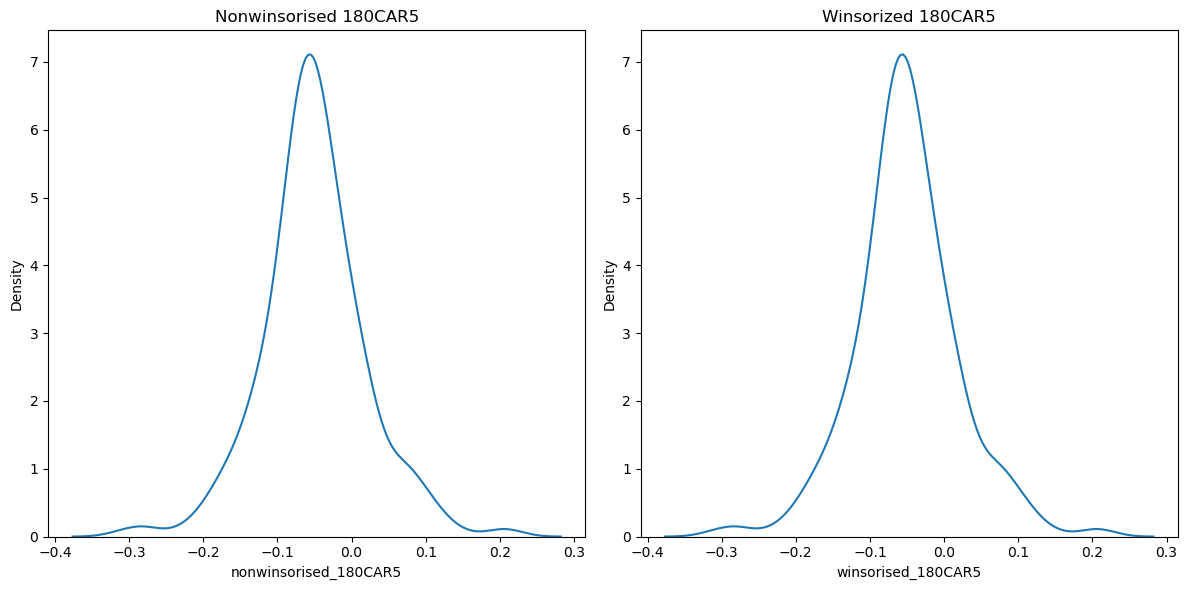

       winsorised_180CAR7  nonwinsorised_180CAR7
count          301.000000             301.000000
mean            -0.101138              -0.101138
std              0.095516               0.095516
min             -0.425623              -0.425623
25%             -0.151998              -0.151998
50%             -0.101783              -0.101783
75%             -0.057011              -0.057011
max              0.526327               0.526327


Top values and their count:  nonwinsorised_180CAR7
0.077703    1
0.093384    1
0.107606    1
0.107727    1
0.108807    1
0.109345    1
0.109513    1
0.120569    1
0.391820    1
0.526327    1
Name: count, dtype: int64





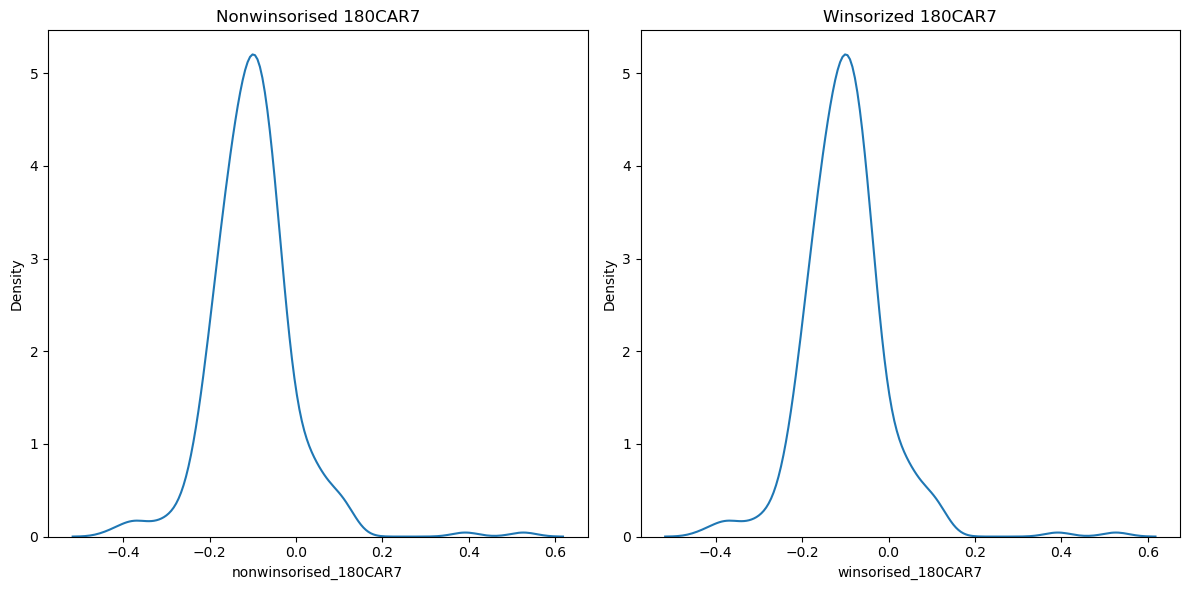

       winsorised_180CAR11  nonwinsorised_180CAR11
count           301.000000              301.000000
mean             -0.196380               -0.196380
std               0.126306                0.126306
min              -0.627395               -0.627395
25%              -0.269527               -0.269527
50%              -0.196213               -0.196213
75%              -0.122990               -0.122990
max               0.255310                0.255310


Top values and their count:  nonwinsorised_180CAR11
0.040585    1
0.054757    1
0.062172    1
0.096331    1
0.106052    1
0.121920    1
0.151251    1
0.230155    1
0.238879    1
0.255310    1
Name: count, dtype: int64





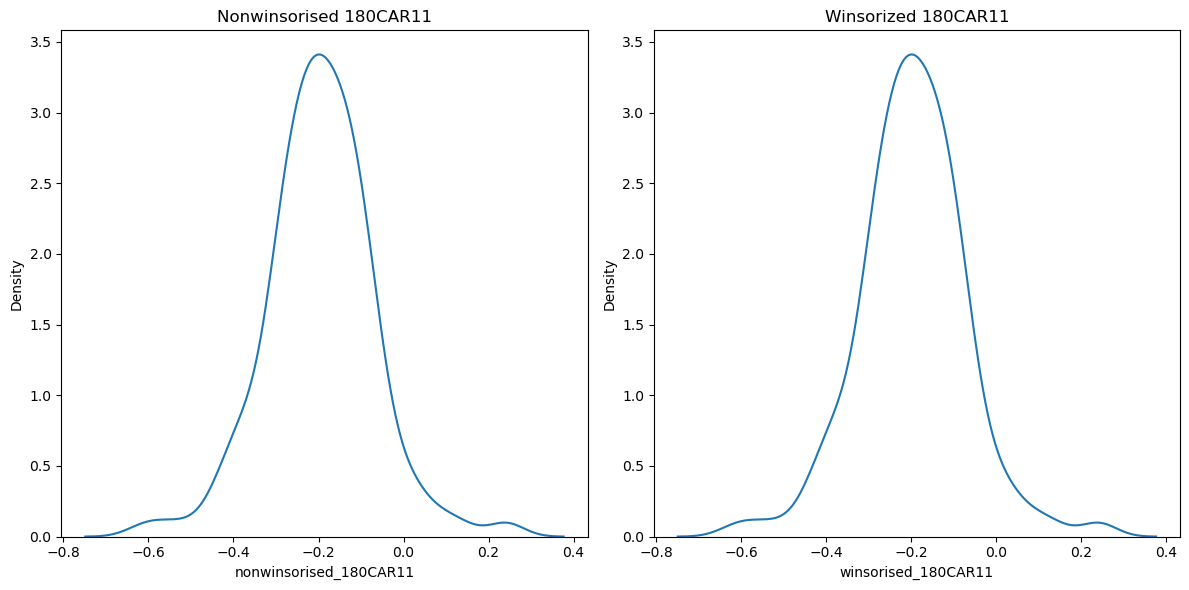

       winsorised_210CAR3  nonwinsorised_210CAR3
count          300.000000             300.000000
mean            -0.003465              -0.003465
std              0.053899               0.053899
min             -0.244071              -0.244071
25%             -0.037708              -0.037708
50%             -0.005396              -0.005396
75%              0.028568               0.028568
max              0.220388               0.220388


Top values and their count:  nonwinsorised_210CAR3
0.098786    1
0.101341    1
0.103245    1
0.107124    1
0.109870    1
0.136419    1
0.160335    1
0.162290    1
0.171668    1
0.220388    1
Name: count, dtype: int64





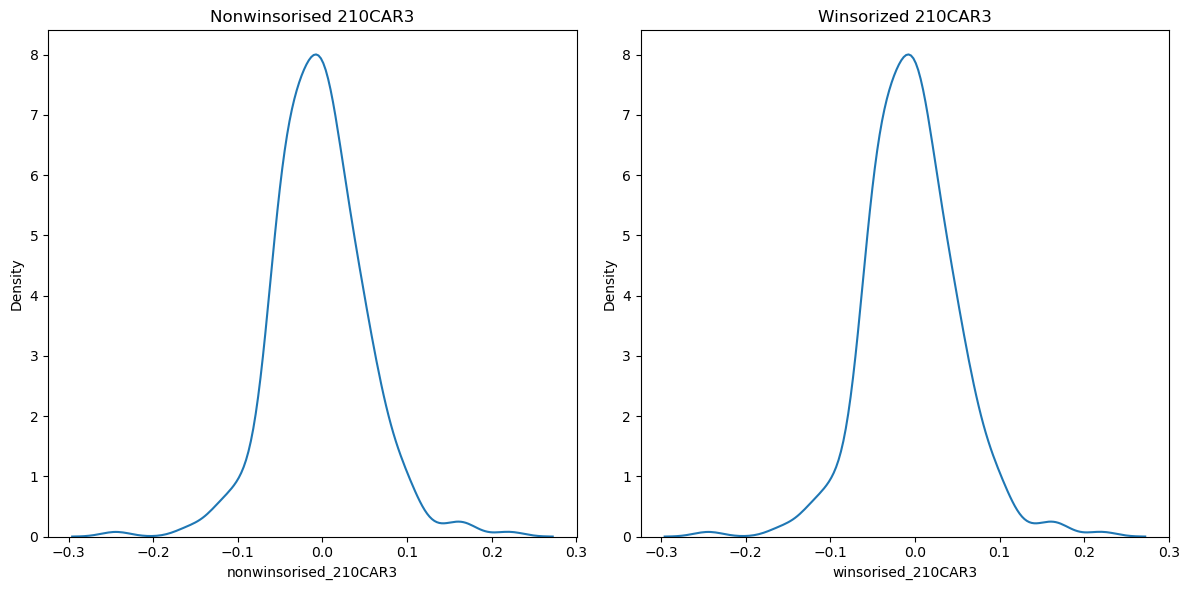

       winsorised_210CAR5  nonwinsorised_210CAR5
count          300.000000             300.000000
mean            -0.050770              -0.050770
std              0.069347               0.069347
min             -0.305161              -0.305161
25%             -0.085218              -0.085218
50%             -0.053126              -0.053126
75%             -0.014903              -0.014903
max              0.216647               0.216647


Top values and their count:  nonwinsorised_210CAR5
0.083372    1
0.092453    1
0.093809    1
0.100271    1
0.107280    1
0.114207    1
0.117053    1
0.136522    1
0.199461    1
0.216647    1
Name: count, dtype: int64





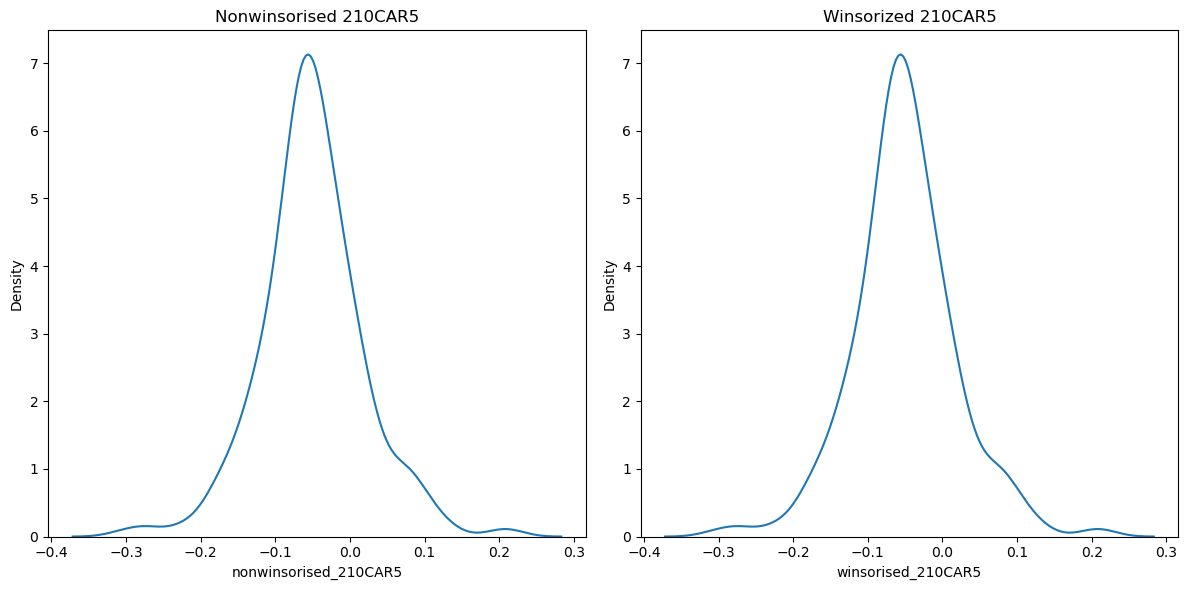

       winsorised_210CAR7  nonwinsorised_210CAR7
count          300.000000             300.000000
mean            -0.102378              -0.102378
std              0.091361               0.091361
min             -0.416962              -0.416962
25%             -0.154994              -0.154994
50%             -0.102689              -0.102689
75%             -0.054966              -0.054966
max              0.540097               0.540097


Top values and their count:  nonwinsorised_210CAR7
0.074246    1
0.079564    1
0.089334    1
0.104459    1
0.105215    1
0.106463    1
0.109270    1
0.112308    1
0.120787    1
0.540097    1
Name: count, dtype: int64





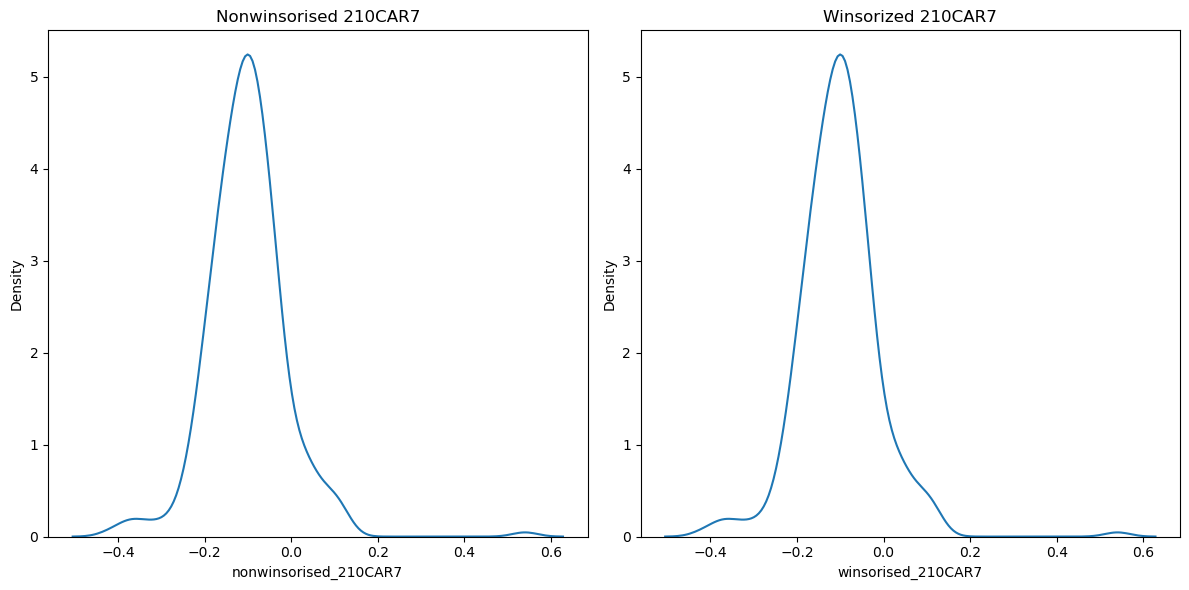

       winsorised_210CAR11  nonwinsorised_210CAR11
count           300.000000              300.000000
mean             -0.197692               -0.197692
std               0.123729                0.123729
min              -0.626474               -0.626474
25%              -0.266765               -0.266765
50%              -0.197309               -0.197309
75%              -0.120715               -0.120715
max               0.268893                0.268893


Top values and their count:  nonwinsorised_210CAR11
0.032907    1
0.046314    1
0.056357    1
0.061741    1
0.092791    1
0.107403    1
0.119170    1
0.147357    1
0.222628    1
0.268893    1
Name: count, dtype: int64





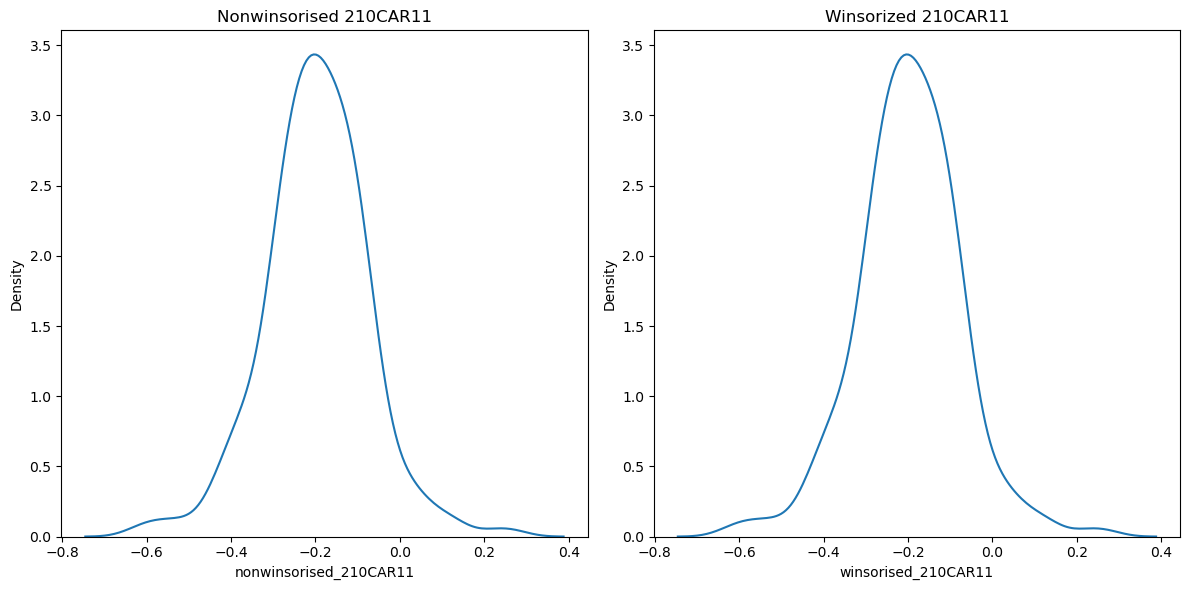

In [31]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

from scipy.stats.mstats import winsorize

def winsorize_output(sample, variable, limits = [0, 0]):
    sample[f"nonwinsorised_{variable}"] = sample[variable]
    sample[f"winsorised_{variable}"] = winsorize(np.array(sample[f"nonwinsorised_{variable}"]), limits = limits, inclusive = [False, False])
    sample[[f"nonwinsorised_{variable}", f"winsorised_{variable}"]].describe()
    print(sample[[f"winsorised_{variable}", f"nonwinsorised_{variable}"]].describe())
    print("\n\nTop values and their count: ", (sample[f"nonwinsorised_{variable}"].value_counts().sort_index().tail(n=10)))
    print("\n\n")
    
    # Graphs
    fig, axes = plt.subplots(1, 2, figsize = (12, 6))
    sns.kdeplot(data = sample[f"nonwinsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[0])
    axes[0].set_title(f'Nonwinsorised {variable}')
    sns.kdeplot(data = sample[f"winsorised_{variable}"].replace([np.inf, -np.inf], np.nan), ax = axes[1])
    axes[1].set_title(f'Winsorized {variable}')
    plt.tight_layout()
    plt.show()

    sample[variable] = sample[f"winsorised_{variable}"]
    return sample[variable]

for car in carCol:
    psmSampleIndep[car] = winsorize_output(psmSampleIndep, car, [0, 0])

In [32]:
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "PC1_FactorScore_Standardised", "ln_dirage", "ln_directorships"
# ]
# filter_datas = []
# CARs = [120, 150, 180, 210]
# for i,CAR in enumerate(CARs):
#     frame = pd. read_pickle(rf"{filtering_folder_path}\Insufficient Data for {CAR}CAR.pkl").rename({"AsOnDate":"Date"}, axis = 1)
#     filter_datas.append(frame)

# carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
#           "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
#           "180CAR3", "180CAR5", "180CAR7", "180CAR11",
#           "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

# print("N for each CAR, no subsampling, dropping for na in control vars + car")

# event_days = [3, 5, 7, 11]

# for i,CAR in enumerate(CARs):
#     frame = psmSampleIndep.merge(filter_datas[i], left_on = ["CompanyName", "Appointment Date"], right_on = ["CompanyName", "Date"], how = "left")
#     for days in event_days:
#         car = f"{CAR}CAR{days}"
#         print(f"{car} N = ", frame.dropna(subset = [car] + controlVars)["na_trading_days"].mean() )

# frame_filtered = frame.dropna(subset=[car] + controlVars)
# frame_filtered["index"] = frame_filtered.index
# frame_filtered.plot(kind="scatter", x="index", y="na_trading_days")

In [33]:
# dirFirm2 = dirFirm.copy()
# psmSampleIndep2 = psmSampleIndep.copy()

# listCol = [
#     "FirstYearPCodeList", "TwoYearPCodeList", "ThreeYearPCodeList", "PCodeList",
#     "FirstYearIndepPCodeList", "TwoYearIndepPCodeList", "ThreeYearIndepPCodeList", "IndepPCodeList",
#     "OtherFirstYearIndepPCode", "OtherTwoYearIndepPCode", "OtherThreeYearIndepPCode", "TotalIndepPCode",
#     "OtherFirstYearPCode", "OtherTwoYearPCode", "OtherThreeYearPCode", "TotalPCode",
#     "OtherFirstYearPCodeIndepExcl","OtherTwoYearPCodeIndepExcl", "OtherThreeYearPCodeIndepExcl", "TotalPCodeIndepExcl",
#     "OtherFirstYearPCodeExcl", "OtherTwoYearPCodeExcl", "OtherThreeYearPCodeExcl", "TotalPCodeExcl"
# ]

# dirFirm2 = dirFirm2.drop(listCol, axis = 1)
# psmSampleIndep2 = psmSampleIndep2.drop(listCol, axis = 1)


# dirFirm2.to_csv("Main_Firm_PSM Ready_no filter v040425.csv")
# psmSampleIndep2.to_csv("Main_Firm_PSM Ready_filter-Indep_gov_fin v040425.csv")


# # # psmSampleAll --> 2101 rows 
# # psmSampleIndep --> 1561 rows 

## PSM --> RookieAppoints as Treatment, NonRookieAppoints as Control

In [34]:
def LogitReg(sample, endog_var, exog_var):
    
    # Logit Regression
    endog = sample[endog_var]
    exog = sample[exog_var]
    
    scaler = StandardScaler()
    exog_standardised = pd.DataFrame(scaler.fit_transform(exog), columns=exog.columns)

    exog_standardised = sm.add_constant(exog_standardised)
    
    log_reg = sm.Logit(endog, exog_standardised).fit()

    propensityScores = log_reg.predict(exog_standardised)
    
    return propensityScores

In [35]:
def MeanDiffTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    if depVar != None:
        dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
        colsAdd = []
        for i in range(-1, 4):
            if i != 0:
                colsAdd.append(f"AsOnYear_T+{i}")
                colsAdd.append(f"{depVar}T+{i}")
                if i>0 :
                    colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
        newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "float")
        sample = pd.concat([sample, newFrame], axis = 1)
        sample = sample.copy()
        
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
        for i in range(-1, 4):
            if i != 0:
                sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
                                                              right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
        for i in range(1, 4):
            if i != 0:
                sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
        sample = sample.copy()
    
    group1 = sample.loc[ sample[endog_var] == 1].copy()
    group2 = sample.loc[ sample[endog_var] == 0].copy()
    
    t_stat, p_value = stats.ttest_ind(group1[car], group2[car], equal_var=False)  # Welch’s t-test (default)

    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Treated Mean:", group1[car].mean(), " Control Mean:", group2[car].mean(), " Diff:", group1[car].mean() - group2[car].mean())
    print("Treated Median:", group1[car].median(), " Control Median:", group2[car].median(), " Diff:", group1[car].median() - group2[car].median())
    print("Treated N:", len(group1[car]), "; Control N:", len(group2[car]))
    print("[treated unique = ", len(group1.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]",\
          "[control unique = ", len(group2.loc[ :, ["Person Code", "Symbol", "AsOnDate"]].drop_duplicates()), "]"
         )
    print("\n")

    # -----------------------------------------------------------------------------------------------------------------
    
    if exog_var != None:
        print("━"*120)
        print(f'{"Matching Variable":<40} {"Treatment":<20} {"Control":<20} {"SMD":<20}')
        print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
        print("-"*120)

        for var in exog_var:
            treatMean = group1[var].mean()
            controlMean = group2[var].mean()
            # p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
            smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
            print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {smd:<20.4f}')
    
        print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    if depVar != None:
        print(depVar, " across years:\n")
        for i in range(1,4):
            sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
        group1 = sample.loc[ sample[endog_var] == 1].copy()
        group2 = sample.loc[ sample[endog_var] == 0].copy()

        print("━"*150, "\n")
        print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
        print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
        print("─"*150, "\n")
    
        for i in range(1,4):
            t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
            treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
            controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
            diffMean = treatedMean - controlMean
    
            treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
            controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
            diffMedian = treatedMedian - controlMedian
    
            print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
            label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            label2 = "Control N: " + str(len(group2[depVar+f'(T+{i}) - (T-1)']))
            
            print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
            print("-"*150, "\n")
            
        print("━"*150, "\n")

    return

In [36]:
def OneSampleTtest(sample, endog_var, exog_var, car, depVar, dirFirm):

    # if depVar != None:
    #     dirFirm = dirFirm.rename( {depVar:f"{depVar}_2"}, axis = 1)
    
    #     colsAdd = []
    #     for i in range(-1, 4):
    #         if i != 0:
    #             colsAdd.append(f"AsOnYear_T+{i}")
    #             colsAdd.append(f"{depVar}T+{i}")
    #             if i>0 :
    #                 colsAdd.append(depVar+f"(T+{i}) - (T-1)")
    
    #     newFrame= pd.DataFrame(columns = colsAdd, data = 0, index = sample.index, dtype = "int")
    #     sample = pd.concat([sample, newFrame], axis = 1)
    #     sample = sample.copy()
        
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"AsOnYear_T+{i}"] = sample["AsOnYear"] + i
    
    #     for i in range(-1, 4):
    #         if i != 0:
    #             sample.loc[:, f"{depVar}T+{i}"] = sample.merge(dirFirm[["Symbol", "AsOnYear", f"{depVar}_2"]].copy(), left_on = ["Symbol", f"AsOnYear_T+{i}"],
    #                                                           right_on = ["Symbol", "AsOnYear"], how = "left")[f"{depVar}_2"]
        
    #     for i in range(1, 4):
    #         if i != 0:
    #             sample.loc[:, depVar+f"(T+{i}) - (T-1)"] = sample[f"{depVar}T+{i}"] - sample[f"{depVar}T+-1"]
    
            
    #     sample = sample.copy()
    sample[car] = winsorize(sample[car], limits = [0.01, 0.01])
    group1 = sample.copy()
    
    t_stat, p_value = stats.ttest_1samp(group1[car], 0)  # Welch’s t-test (default)
    
    print("\n")
    print(car, ":")
    print("\n")
    print("T Statistic:", t_stat, " P Value:",p_value)
    print("Mean:", group1[car].mean())
    print("Median:", group1[car].median())
    print("N:", len(group1[car]))

    print("\n")

    # -----------------------------------------------------------------------------------------------------------------




    # if exog_var != None:
    #     print("━"*120)
    #     print(f'{"Matching Variable":<40} {"Treatment Firms":<20} {"Control Firms":<20} {"Test of Diff (p value)":<20}')
    #     print(f'{" ":<40} {"N = " + str(len(group1[car])):<20} {"N = " + str(len(group2[car])):<20}')
    #     print("-"*120)

    #     for var in exog_var:
    #         treatMean = group1[var].mean()
    #         controlMean = group2[var].mean()
    #         p_value = stats.ttest_ind(group1[var], group2[var], equal_var=False)[1]
    #         print(f'{var:<40} {treatMean:<20.4f} {controlMean:<20.4f} {p_value:<20.4f}')
    
    #     print("━"*120, "\n")
    
    # -----------------------------------------------------------------------------------------------------------------


    # if depVar != None:
    #     print(depVar, " across years:\n")
    #     for i in range(1,4):
    #         sample = sample.dropna(subset = [depVar+f'(T+{i}) - (T-1)'])
    
    #     group1 = sample.loc[ sample[endog_var] == 1].copy()
    #     group2 = sample.loc[ sample[endog_var] == 0].copy()

    #     print("━"*150, "\n")
    #     print(f'{depVar:<40}{" ":<20}{"Treatment Firms":<20}{"Control Firms":<20}{"Difference":<20}{"Test of Diff":<20}{"Test of Diff"}')
    #     print(f'{" ":<120}{"(t stat)":<20}{"(p value)":<20}')
    
    #     print("─"*150, "\n")
    
    #     for i in range(1,4):
    #         t_stat2, p_value2 = stats.ttest_ind(group1[depVar+f'(T+{i}) - (T-1)'], group2[depVar+f'(T+{i}) - (T-1)'], equal_var=False)  # Welch’s t-test (default)
            
    #         treatedMean = group1[depVar+f'(T+{i}) - (T-1)'].mean()
    #         controlMean = group2[depVar+f'(T+{i}) - (T-1)'].mean()
    #         diffMean = treatedMean - controlMean
    
    #         treatedMedian = group1[depVar+f'(T+{i}) - (T-1)'].median()
    #         controlMedian = group2[depVar+f'(T+{i}) - (T-1)'].median()
    #         diffMedian = treatedMedian - controlMedian
    
    #         print(f'{"Year_T+" + str(i) +" - Year_T-1":<40}{"<MEAN>":<20}{treatedMean:<20.4f}{controlMean:<20.4f}{diffMean:<20.4f}{t_stat2:<20.4f}{p_value2:<20.10f}')
    
    #         label1 = "Treated N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
    #         label2 = "Control N: " + str(len(group1[depVar+f'(T+{i}) - (T-1)']))
            
    #         print(f'{label1 + " "*5 + label2:<40}{"<MEDIAN>":<20}{treatedMedian:<20.4f}{controlMedian:<20.4f}{diffMedian:<20.4f}')
            
    #         print("-"*150, "\n")
            
    #print("━"*150, "\n")

    return

In [37]:
def PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    treated = sample.loc[ sample[endog_var] == 1].copy()
    control = sample.loc[ sample[endog_var] == 0].copy()

    # Nearest Neighbours
    nn = NearestNeighbors(n_neighbors = 1, metric = "euclidean")
    nn.fit(control[["propensityScore"]])

    distances, indices = nn.kneighbors(treated[["propensityScore"]])
    
    matchedControl = control.iloc[indices.flatten()].copy()
    
    matched = pd.concat([treated, matchedControl])
    matched.reset_index(drop=True, inplace=True)

    MeanDiffTtest(matched, endog_var, exog_var, car, depVar, dirFirm)

    return

In [38]:
# Func PSM non replacement
def PsmNonReplac(sample, endog_var, exog_var, car, depVar, dirFirm):

    # Logit Regression
    sample.loc[:, "propensityScore"] = LogitReg(sample, endog_var, exog_var)

    # Separate treated and control groups
    treated = sample[sample[endog_var] == 1].copy()
    control = sample[sample[endog_var] == 0].copy()
    
    # Compute pairwise distances (absolute difference in propensity scores)
    dist_matrix = cdist(treated[['propensityScore']], control[['propensityScore']], metric='euclidean')
    
    # Match without replacement
    treated_indices = []
    matched_indices = []
    used_control_indices = set()
    
    for i in range(len(treated)):
        if len(used_control_indices) >= len(control):  # Stop if no controls left
            print("Warning: Not enough control units to match all treated units.")
            break
        
        # Get nearest control unit index that hasn't been used
        match_idx = np.argmin(dist_matrix[i])
        
        while match_idx in used_control_indices:  # Ensure it's not already matched
            dist_matrix[i, match_idx] = np.inf  # Temporarily set distance to infinity

            if np.all(dist_matrix[i] == np.inf):  # If all controls are exhausted
                print(f"No available control for treated unit {i}, skipping.")
                match_idx = None
                break
            
            match_idx = np.argmin(dist_matrix[i])
        
        used_control_indices.add(match_idx)
        matched_indices.append(match_idx)
        treated_indices.append(i)
    
    # Retrieve matched units
    matched_control = control.iloc[matched_indices].copy()
    matched_treated = treated.iloc[treated_indices].copy()
    
    # Combine matched treated and control units
    matched_data = pd.concat([matched_treated.reset_index(drop=True), matched_control.reset_index(drop=True)])
    
    # Reset index
    matched_data.reset_index(drop=True, inplace=True)


    # Mean difference and T Test
    MeanDiffTtest(matched_data, endog_var, exog_var, car, depVar, dirFirm)

    return
    


In [39]:
def prep_sample(sample, car, controlVars, yearDummy = 0, industryDummy = 0) -> tuple[pd.DataFrame, list[str]]:
    
    sample = sample.replace([np.inf, -np.inf], pd.NA).dropna(subset = [car] + controlVars).reset_index(drop=True)

    if yearDummy == 1:
        yearDummies = pd.get_dummies( sample["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = yearDummies.sum().loc[ yearDummies.sum() == 1 ].index.values
        yearDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, yearDummies], axis = 1)
    else:
        yearDummies = pd.DataFrame()
    
    if industryDummy == 1:
        industryDummies = pd.get_dummies( sample["NIC_1digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
        dummiesWithOnlyOneFirm = industryDummies.sum().loc[ industryDummies.sum() == 1 ].index.values
        industryDummies.drop(dummiesWithOnlyOneFirm, axis = 1, inplace = True)
        sample = pd.concat([sample, industryDummies], axis = 1)
    else:
        industryDummies = pd.DataFrame()

    exog_var = controlVars + yearDummies.columns.to_list() + industryDummies.columns.to_list()

    # checking for multicollinearity
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    from statsmodels.tools.tools import add_constant
    exog_with_const = add_constant(sample[exog_var])
    
    vif_data = pd.DataFrame()
    vif_data["feature"] = exog_with_const.columns
    vif_data["VIF"] = [variance_inflation_factor(exog_with_const.values, i)
                       for i in range(exog_with_const.shape[1])]
    highCollinearity = [x for x in 
                    vif_data.loc[ vif_data["VIF"] > 10 ]["feature"].values
                    if x!="const"]
    exog_var = [x for x in exog_var if x not in highCollinearity]    
    
    return sample, exog_var

# PSM on PCA output + other controls

In [40]:
controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep",
               "Promoters_percent", "NonpromoterInstitutions_percent",
               "ln_marcap", "ln_rdtoassets", "Debt to equity ratio"]

controlVars = ["PercentWomenDir", "PercentBusyDir",
               "LnBoardSize", "PercentIndep"]
# controlVars = [
#     "NonpromoterInstitutions_percent", "ln_marcap", "Debt to equity ratio",
    
#     "Skilllist_FactorScore", "ln_dirage", "ln_directorships"
# ]

#PsmReplac(sample, endog_var, exog_var, car, depVar, dirFirm)

# No Higher level Filtration

## Version 0: No filtration

## No fixed effects

### PSM with replacement

In [41]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

Optimization terminated successfully.
         Current function value: 0.301916
         Iterations 7


120CAR3 :


T Statistic: 1.1734781937099712  P Value: 0.2459966983588794
Treated Mean: 0.002091863033511835  Control Mean: -0.012966183626397237  Diff: 0.015058046659909072
Treated Median: -0.0037054096836927133  Control Median: -0.01750428569573889  Diff: 0.013798876012046178
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  26 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1592               0.1577               0.0173              
Perce

In [42]:
sample

,index,Symbol,Company,AsOnDate,AsOnYear,ISIN,Person Code,Director Salutation,Director First Name,Director Middle Name,Director Surname,Date of Birth,Gender,Nationality,Member of Civil Services,Promoter Director (Yes/No),Position on Board,Independent (Yes/No),Education1,Education2,Education3,Education4,Education5,Education6,Education7,Education8,Education9,Education10,Skills/Competencies,Occupation,Cessation Reason,Other Directorship 1,Other Directorship 2,Other Directorship 3,Other Directorship 4,Other Directorship 5,Other Directorship 6,Other Directorship 7,Other Directorship 8,Other Directorship 9,Other Directorship 10,Other Directorship 11,Other Directorship 12,Other Directorship 13,Other Directorship 14,Other Directorship 15,Brief Profile,Tenure Valid till,Date of Demise,Indep,Appointment Date,Cessation Date,PrevLastServed,NextServed,CessationDummy,ReappointDummy,TermStartDummy,TermNumber,AppointDummy,CumOpBalUnc,CumOpBalIndep,CumOpBalNonIndep,CumCloBalUnc,CumCloBalIndep,CumCloBalNonIndep,TermOpBalUnc,TermOpBalIndep,TermOpBalNonIndep,TermOpBalTotal,TermCloBalUnc,TermCloBalIndep,TermCloBalNonIndep,TermCloBalTotal,CompOpBalUnc,CompOpBalIndep,CompOpBalNonIndep,CompOpBalTotal,CompCloBalUnc,CompCloBalIndep,CompCloBalNonIndep,CompCloBalTotal,CloBalTotalXP,AllPastDirect,CurrDirectA,CurrDirectAB,PastSiezedDirectA,PastSiezedDirectAB,CountOtherPastUnclearA,CountOtherPastIndepA,CountOtherPastNonIndepA,CompCountOtherPastTotalA,CountOtherPastUnclearAB,CountOtherPastIndepAB,CountOtherPastNonIndepAB,CompCountOtherPastTotalAB,CountCurrUnclearA,CountCurrIndepA,CountCurrNonIndepA,CompCountCurrTotalA,CountCurrUnclearAB,CountCurrIndepAB,CountCurrNonIndepAB,CompCountCurrTotalAB,Rookie,IsIndep,IsNonIndep,IsRookie,IsNonRookie,IsCeoMDPosition,IsChairmanPosition,IsCeoMDOccupation,IsChairmanOccupation,IsCeoMD,IsChairman,IsPromoterClassification,IsPromoterBoard,IsPromoter,IsDualityChairmanMD,IsFamilyManager,IsFamilyChairman,IsFamilyChairmanAndCEO,IsRookieIndep,IsRookieNonIndep,IsNonRookieIndep,IsNonRookieNonIndep,IsFemale,Age,TenureInYearsinCompIndep,TenureInYearsinCompTotal,TenureInYearsTotal,IsFirstTerm,IsFirstTermIndep,IsZeroYear,IsZeroYearIndep,IsOneYear,IsOneYearIndep,IsTwoYear,IsTwoYearIndep,IsThreeYear,IsThreeYearIndep,IsRetires5y,IsTermLimitRetirement,IsDefaultTerm,IsBusy,IsTurnOver,HasRetires5y,HasTermLimitRetirement,IsTurnOverIndep,NSE symbol,NIC code,Entity type,Ownership group,Ownership group code,Prowess company code,CompanyName,govtdummy,findummy,Skills,EducationAll,IsMBA,IsPhD,AllPastDirectNIC,CurrDirectANIC,CurrDirectABNIC,AllNIC,AllPastDirectNIC_2Digit,AllNIC_Industry,HasFinanceXP,HasTechXP,HasRelatedIndustryXP,IsExecCurrent,NumExecAll,IsOutsideExecXP,HasExecXP,PublicExecXPDummy,PrivateExecXPDummy,HasPublicExecXP,HasPrivateExecXP,SkillsInPositiononBoard,SkillsInOccupation,SkillsInBriefProfile,AllSkills,HasTechSkill,HasFinanceSkill,FirmsPast,NumSkills_gai,NumFirmsPast,NumIndustryPast,HasCeoMDChairXP,HasConglomerateXP,Academic,Outside Board,Company Business,skilllist_sustainability,skilllist_entrepreneurial,skilllist_compensation,skilllist_conglomerate_experience,skilllist_hr,skilllist_technology,skilllist_finance_accounting,skilllist_governance,skilllist_government_policy,skilllist_international,skilllist_leadership,skilllist_legal,skilllist_marketing,skilllist_risk_management,skilllist_scientific,skilllist_strategic_planning,skilllist_manufacturing_supply_chain,Manufacturing_NIC_not used,profile_sustainability,profile_entrepreneurial,profile_compensation,profile_conglomerate_experience,profile_hr,profile_technology,profile_finance_accounting,profile_governance,profile_government_policy,profile_international,profile_leadership,profile_legal,profile_marketing,profile_risk_management,profile_scientific,profile_strategic_planning,profile_manufacturing_supply_chain,Committee Name,committee_sustainability,committee_entrepreneurial,committee_compensation,committee_conglomerate_experience,committee_hr,committee_technology,committee_finance_

## Using Year fixed effects

### PSM with replacement

In [43]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

         Current function value: 0.278054
         Iterations: 35


120CAR3 :


T Statistic: 1.1534716346930776  P Value: 0.25391899750382246
Treated Mean: 0.002091863033511835  Control Mean: -0.01226599800662404  Diff: 0.014357861040135875
Treated Median: -0.0037054096836927133  Control Median: -3.417764270449708e-05  Diff: -0.0036712320409882163
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  24 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1592               0.1552               0.0440              
PercentBusyDir                       

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


         Current function value: 0.278054
         Iterations: 35


120CAR7 :


T Statistic: 1.1611276215862576  P Value: 0.252987117876902
Treated Mean: -0.10033661922160864  Control Mean: -0.12765226417851414  Diff: 0.0273156449569055
Treated Median: -0.11463211714898411  Control Median: -0.12484092650404884  Diff: 0.010208809355064727
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  24 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1592               0.1552               0.0440              
PercentBusyDir                           0.2110

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg



150CAR3 :


T Statistic: 1.3486492150548197  P Value: 0.18317696430426367
Treated Mean: 0.0026007603273354146  Control Mean: -0.014254060156065358  Diff: 0.01685482048340077
Treated Median: 0.006026959935070478  Control Median: -0.006728238150458116  Diff: 0.012755198085528593
Treated N: 29 ; Control N: 29
[treated unique =  29 ] [control unique =  24 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 29               N = 29              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1592               0.1552               0.0440              
PercentBusyDir                           0.2110               0.2097               0.0047              
LnB

...

C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarnin

         Current function value: 0.275300
         Iterations: 35


210CAR3 :


T Statistic: 1.2040890496210377  P Value: 0.23421244180330017
Treated Mean: -0.0006551512212890105  Control Mean: -0.015147929577796917  Diff: 0.014492778356507906
Treated Median: 0.0042414973286491395  Control Median: 0.0006899601784512537  Diff: 0.003551537150197886
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  24 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1578               0.1701               -0.1258             
PercentBusyDir                        

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)
C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Converg

         Current function value: 0.275300
         Iterations: 35


210CAR11 :


T Statistic: 0.14872340422238828  P Value: 0.8823260259699246
Treated Mean: -0.19275274947840484  Control Mean: -0.19713864402488332  Diff: 0.004385894546478475
Treated Median: -0.17153555776724277  Control Median: -0.20349429546826542  Diff: 0.031958737701022644
Treated N: 28 ; Control N: 28
[treated unique =  28 ] [control unique =  24 ]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Matching Variable                        Treatment            Control              SMD                 
                                         N = 28               N = 28              
------------------------------------------------------------------------------------------------------------------------
PercentWomenDir                          0.1578               0.1701               -0.1258             
PercentBusyDir                           0

C:\Users\SHIVAM\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\SHIVAM\AppData\Local\Temp\ipykernel_16152\2464609904.py:64: RuntimeWarning: invalid value encountered in scalar divide
  smd = (group1[var].mean() - group2[var].mean()) / np.sqrt((group1[var].var() + group2[var].var()) / 2)


## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [ ]:
psmSampleIndep1 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [ ]:
psmSampleIndep2 = psmSampleIndep.loc[ (psmSampleIndep["promoterholding25"]==1) & (psmSampleIndep["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Higher level Filteration: DUPLICATED DIRECTORS REMOVED

## Version 0: No filtration

In [ ]:
# psmSampleIndep0 = psmSampleIndep.copy()

# yearDummies0 = pd.get_dummies( psmSampleIndep0["AsOnYear"], prefix = "YearDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearDummies0 = pd.concat([psmSampleIndep0, yearDummies0], axis = 1)

# industryDummies0 = pd.get_dummies( psmSampleIndep0["NIC_2digit"], prefix = "IndustryDummy_", drop_first = True, dtype = "int")
# psmSampleIndepWithYearIndustryDummies0 = pd.concat([psmSampleIndepWithYearDummies0, industryDummies0], axis = 1)

# depVar = None

In [ ]:
duplicated = psmSampleIndep.duplicated(subset = ["Symbol", "Appointment Date"], keep = False).to_frame("val")
filtered_index = duplicated.loc[duplicated["val"] == False].index
psmSampleIndep_filtered = psmSampleIndep.loc[filtered_index].copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None



for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep_filtered, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
# sample0 = psmSampleIndepWithYearIndustryDummies0.replace([np.inf, -np.inf], pd.NA).copy()
# exog_var = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
# sample = sample0.dropna(subset = [car] + exog_var).reset_index(drop=True).copy()
# sample[exog_var].T[sample[exog_var].T.duplicated(keep = False) == True ].index
# sample.describe()

# Version 1: promoterholding25==1 & hasfamilychairmanandceo==1

In [ ]:
psmSampleIndep1 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==1) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", controlVars, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep1, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

# Version 2: promoterholding25==1 & hasfamilychairmanandceo==0

In [ ]:
psmSampleIndep2 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==1) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep2, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 3: Non family firms promoterholding25==0 & hasfamilychairmanandceo==0

In [ ]:
psmSampleIndep3 = psmSampleIndep_filtered.loc[ (psmSampleIndep_filtered["promoterholding25"]==0) & (psmSampleIndep_filtered["HasFamilyChairmanAndCEO"]==0) ].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 0, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 0)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars, 1, 1)
    PsmReplac(sample, "IsRookieIndep", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

# Version 4: Rookie in Family firms vs Rookie in non family firms, family firms => promoterholding25 == 1, HasFamilyChairmanAndCEO == 1; non family ==0 for both

IMPORTANT NOTE!!!!!!!!!!!!
promoters_percent resulted in singular matrices and therefore has been removed from the covariates

In [ ]:
filtered = psmSampleIndep_filtered.loc[ psmSampleIndep_filtered["IsRookieIndep"] == 1].copy()

filtered["familyfirm_dummy"] = np.where((filtered["promoterholding25"]==1) & (filtered["HasFamilyChairmanAndCEO"]==1),
                                                1,0)
filtered["nonfamilyfirm_dummy"] = np.where((filtered["promoterholding25"]==0) & (filtered["HasFamilyChairmanAndCEO"]==0),
                                                1,0)
                                                
psmSampleIndep3 = filtered.loc[ ((filtered["familyfirm_dummy"] == 1) | 
                                 (filtered["nonfamilyfirm_dummy"] == 1))].reset_index(drop = True).copy()

## No fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 0, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

## Using Year fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]

depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 0)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

## Using Year + Industry fixed effects

### PSM with replacement

In [ ]:
carCol = ["120CAR3", "120CAR5", "120CAR7", "120CAR11", 
          "150CAR3", "150CAR5", "150CAR7", "150CAR11", 
          "180CAR3", "180CAR5", "180CAR7", "180CAR11",
          "210CAR3", "210CAR5", "210CAR7", "210CAR11"]


depVar = None
controlVars2 = [x for x in controlVars if x != "Promoters_percent"]

for car in carCol:
    sample, exog_var = prep_sample(psmSampleIndep3, car, controlVars2, 1, 1)
    PsmReplac(sample, "familyfirm_dummy", exog_var, car, depVar, dirFirm)

In [ ]:
    # singular_col = []
    # for col in industryDummies0.columns.to_list():
    #     if sample[col].std() == 0:
    #         singular_col.append(col)

    # sample.drop(singular_col, axis = 1, inplace = True)
    # exog_var_all = controlVars + yearDummies0.columns.to_list() + industryDummies0.columns.to_list()
    # exog_var = [x for x in exog_var_all if x not in singular_col]

In [ ]:
# endog_var = "familyfirm_dummy"
# endog = sample[[endog_var]]
# exog = sample[[x for x in exog_var if x != "Promoters_percent"]]
# exog = sm.add_constant(exog)

# log_reg = sm.Logit(endog, exog).fit()

# propensityScores = log_reg.predict(exog)

# sample[["Promoters_percent", "familyfirm_dummy"]]

# pd.crosstab(sample["Promoters_percent"], sample["familyfirm_dummy"])

# exog_var